In [2]:
import lsdb
from upath import UPath
from dask.distributed import Client
from lsdb.streams import CatalogStream
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
    }
)

In [3]:
import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

In [4]:
print(lsdb.__version__)

0.10.5.dev1+g36a32399e


# Using LSDB to Perform Large Crossmatches with Early Data Preview 2 (EDP2)

In this notebook we'll show how to:

* Load the HATS-formatted version of DP2 on the Rubin Science Platform (RSP)
* Load an external HATS catalog
* Apply column-based filtering on catalogs
* Perform large crossmatches between DP2 and other catalogs
* Demonstrate how to use Catalog streaming to overcome significant data volume
* Plot some resulting lightcurves

## Load Data Preview 2

We begin by loading in DP2, specifying just ra and dec columns to have the lightest weight catalog possible. In practice, trimming down columns to only the subset you'll need for analysis can greatly help in avoiding memory-related issues during computation.

> **Tip**: It's fine to load them all lazily at first and then trim down later once you've solidified a workflow.

In [5]:
dp2_path = UPath("/rubin/lsdb_data/object_collection")

dp2 = lsdb.open_catalog(dp2_path, columns=["coord_ra", "coord_dec"])
dp2

,coord_ra,coord_dec
npartitions=8840,,
"Order: 8, Pixel: 10240",double[pyarrow],double[pyarrow]
...,...,...
"Order: 5, Pixel: 12283",...,...
"Order: 5, Pixel: 12284",...,...


## Load another Catalog - Gaia DR3

We'll now load Gaia remotely as a second catalog for future crossmatching. Again, we're limiting our column loading to only columns we'll need.

Many public catalogs are available to load directly with LSDB — you can browse them at [data.lsdb.io](https://data.lsdb.io).

In [6]:
# Open from a remote s3 bucket
gaia = lsdb.open_catalog(
    "s3://stpubdata/gaia/gaia_dr3/public/hats",
    columns=[
        "ra",
        "dec",
        "parallax",
        "parallax_over_error",
        "teff_gspphot",
        "logg_gspphot",
        "classprob_dsc_combmod_star",
    ],
)
gaia

,ra,dec,parallax,parallax_over_error,teff_gspphot,logg_gspphot,classprob_dsc_combmod_star
npartitions=2016,,,,,,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow]
...,...,...,...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...,...,...


### Query Gaia: Filtering for FGK Stars

`Catalog.query` allows us to apply filters based on column values, in this case we'll apply a set of cuts to select for FGK Stars.

In [7]:
gaia_filtered = gaia.query("parallax > 0 and parallax_over_error > 5 and \
    teff_gspphot > 5380 and teff_gspphot < 7220 and logg_gspphot > 4.5 \
    and logg_gspphot < 4.72 and classprob_dsc_combmod_star > 0.5")

### Perform a Crossmatch

Now we're ready to crossmatch DP2 and our filtered Gaia DR3.

In [8]:
xmatch = dp2.crossmatch(gaia_filtered, suffix_method="overlapping_columns")
xmatch

,coord_ra,coord_dec,ra,dec,parallax,parallax_over_error,teff_gspphot,logg_gspphot,classprob_dsc_combmod_star,_dist_arcsec
npartitions=9139,,,,,,,,,,
"Order: 8, Pixel: 10240",double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12283",...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12284",...,...,...,...,...,...,...,...,...,...


## Count the Resulting Matches

At this point, we're just interested in the number of matches we found, so we'll construct a small function to apply through `Catalog.map_partition` which counts the number of matches in each output partition.

In [9]:
# Write a simple map_partitions function to count resulting matches
def count_matches(df):
    return {"n_matches": len(df)}


matches_by_partition = xmatch.map_partitions(count_matches)

## Performing Computation

For computation, we establish a Dask Client and dictate a number of workers and memory limit per worker. The Dask client will work within it's boundaries to perform the computation that we kick off with `Catalog.compute()` in parallel.

In [12]:
# Define a client, and .compute() the match result
with Client(n_workers=4, threads_per_worker=1, memory_limit="4GB") as client:
    print(f"Dask dashboard: {client.dashboard_link}")
    match_df = matches_by_partition.compute()
    client.close()

Computing Catalog:   0%|          | 0/9139 [00:00<?, ?it/s]

Finally we can check the total number of Gaia-filtered FGK stars we matched in DP2:

In [13]:
print(f"Number of Matches: {match_df["n_matches"].sum()}")

Number of Matches: 548168


## Including Lightcurves
Let's start again, but this time we'll add the "ObjectForcedSource" column, which includes our lightcurves, with the goal of inspecting a few of them.

In [14]:
dp2_lc = lsdb.open_catalog(dp2_path, columns=["coord_ra", "coord_dec", "objectForcedSource"])
dp2_lc

,coord_ra,coord_dec,objectForcedSource
npartitions=8840,,,
"Order: 8, Pixel: 10240",double[pyarrow],double[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
...,...,...,...
"Order: 5, Pixel: 12283",...,...,...
"Order: 5, Pixel: 12284",...,...,...


A common operation is to filter lightcurve lengths, we lack a pre-existing column to tell us the lengths, so we'll take advantage of our nested column itself to perform the filter:

In [15]:
# query for lightcurves with at least 50 observations
def filter_lengths(nf):
    # define a function that applies to each dataframe partition
    return nf[nf["objectForcedSource"].len() > 50]  # nested columns have a direct len()


dp2_lc_filtered = dp2_lc.map_partitions(filter_lengths)

Now we can redo our crossmatch with Gaia: 

In [16]:
xmatch_lc = dp2_lc_filtered.crossmatch(gaia_filtered, suffix_method="overlapping_columns")
xmatch_lc

,coord_ra,coord_dec,objectForcedSource,ra,dec,parallax,parallax_over_error,teff_gspphot,logg_gspphot,classprob_dsc_combmod_star,_dist_arcsec
npartitions=9139,,,,,,,,,,,
"Order: 8, Pixel: 10240",double[pyarrow],double[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou...",double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12283",...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12284",...,...,...,...,...,...,...,...,...,...,...


In [17]:
# And re-initialize our counting result
def count_matches(df):
    return {"n_matches": len(df)}


matches_by_partition_lc = xmatch_lc.map_partitions(count_matches)

## Dealing with Heavy Workloads - Catalog Streaming

However, our added lightcurves add a ton of weight to the DP2 catalog. If you check the estimated catalog size when we first loaded the catalogs, you can see that DP2 was ~20GB total when loading just the "coord_ra" and "coord_dec" columns, but with "objectForcedSource" this balloons to ~1.3TB. Due to this, it's likely that direct computation on a RSP environment (4 cores, 32GB total) will fail. We can take advantage of an alternative computation method, Catalog Streaming, in cases like this:

In [19]:
%%time
match_stream = CatalogStream(xmatch_lc, partitions_per_chunk=4, shuffle=False)

chunks = []
# 16 GB workers end up being needed to perform this workflow
with Client(n_workers=1, threads_per_worker=1, memory_limit="16GB") as client:
    print(f"Dask dashboard: {client.dashboard_link}")
    print(client)
    match_iter = iter(match_stream)
    for i in range(50):
        chunks.append(next(match_iter))
    client.close()
match_df = pd.concat(chunks)
match_df

<Client: 'tcp://127.0.0.1:4751' processes=1 threads=1, memory=14.90 GiB>
CPU times: user 14 s, sys: 2.27 s, total: 16.3 s
Wall time: 8min 48s


coord_ra  coord_dec  \
_healpix_29                                  
3452204825677797065  305.946264 -10.583908   
3452205377521584693   305.72863 -10.691067   
...                         ...        ...   
3446079389607726776  318.778544  -11.21482   
3446079795773327934  318.931181 -11.198158   

                                                    objectForcedSource  \
_healpix_29                                                              
3452204825677797065  [{parentObjectId: 0, coord_ra: 305.946264, coo...   
3452205377521584693  [{parentObjectId: 0, coord_ra: 305.72863, coor...   
...                                                                ...   
3446079389607726776  [{parentObjectId: 0, coord_ra: 318.778544, coo...   
3446079795773327934  [{parentObjectId: 0, coord_ra: 318.931181, coo...   

                             ra        dec  parallax  parallax_over_error  \
_healpix_29                                                                 
3452204825677797065  305.946255 -10.583901  0.710761            20.467844   
3452205377521584693  305.728641 -10.691061  0.460955            10.544349   
...                         ...        ...       ...                  ...   
3446079389607726776  318.778561 -11.214815  0.601171            13.863623   
3446079795773327934   318.93119 -11.198121  0.413757             9.959193   

                     teff_gspphot  logg_gspphot  classprob_dsc_combmod_star  \
_healpix_29                                                                   
3452204825677797065    5504.50293        4.5516                    0.999955   
3452205377521584693   5609.919922        4.5009                    0.999961   
...                           ...           ...                         ...   
3446079389607726776   5589.259277        4.5758                    0.999956   
3446079795773327934   6060.625488        4.5823                    0.999972   

                     _dist_arcsec  
_healpix_29                        
3452204825677797065      0.039326  
3452205377521584693      0.046429  
...                           ...  
3446079389607726776      0.065492  
3446079795773327934      0.138695  

[1971 rows x 11 columns]

Above, we've streamed the result for the first 200 partitions (4 partitions per chunk, 50 chunks grabbed). We ultimately found 11 lightcurves that matched our criteria. Let's end by plotting one of them:

In [20]:
lc = match_df.iloc[0]["objectForcedSource"]
lc

,parentObjectId,coord_ra,coord_dec,visit,detector,band,psfFlux,psfFluxErr,psfFlux_flag,psfDiffFlux,...,tract,patch,psfMag,psfMagErr,midpointMjdTai,psfFluxErr_corrected,psfFluxErr_corrected_flag,psfDiffFluxErr_corrected,psfDiffFluxErr_corrected_flag,psfMagErr_corrected
0,0,305.946264,-10.583908,2025062000415,11,i,4.204871e+05,551.586121,False,-2.398203e+06,...,7743,83,17.340618,0.001424,60847.236666,4696.559570,False,2157.076660,False,0.012127
1,0,305.946264,-10.583908,2025062000458,181,i,3.382192e+06,1910.429321,False,4.734175e+05,...,7743,83,15.077004,0.000613,60847.256542,30366.257812,False,4757.828613,False,0.009748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,0,305.946264,-10.583908,2025072800441,14,i,3.349842e+06,1852.315796,False,3.979522e+05,...,7743,83,15.087439,0.000600,60885.357343,30350.798828,False,4599.051758,False,0.009837
52,0,305.946264,-10.583908,2025072800489,14,z,3.589231e+06,2230.597900,False,7.802666e+05,...,7743,83,15.012497,0.000675,60885.380867,32634.371094,False,6119.346680,False,0.009872


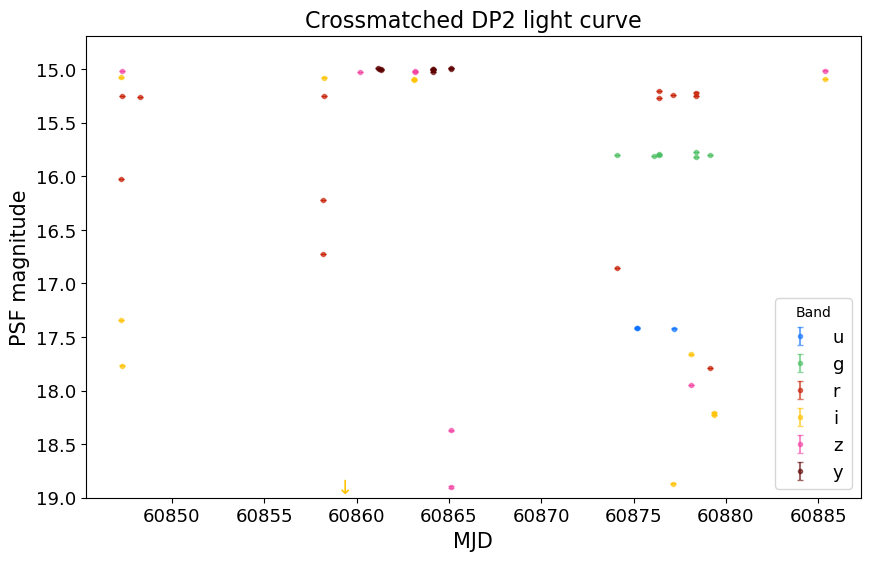

In [33]:
band_colors = {
    "u": "#0c71ff",
    "g": "#49be61",
    "r": "#c61c00",
    "i": "#ffc200",
    "z": "#f341a2",
    "y": "#5d0000",
}

mag_cut = 19.0  # faint-end cutoff (inverted magnitude axis)

fig, ax = plt.subplots(figsize=(10, 6))

# One error-bar series per band, colored by filter, with capped error bars
for band in band_colors:
    grp = lc[lc["band"] == band]
    if len(grp) == 0:
        continue
    ax.errorbar(
        grp["midpointMjdTai"],
        grp["psfMag"],
        yerr=grp["psfMagErr"],
        fmt="o",
        markersize=3,
        alpha=0.6,
        ls="none",
        capsize=2,
        color=band_colors[band],
        label=band,
    )

# Inverted axis, cut off at the faint end (mag 19); brighter objects sit higher
top = lc.loc[lc["psfMag"] <= mag_cut, "psfMag"].min() - 0.3
ax.set_ylim(mag_cut, top)

# Points fainter than the cutoff fall off the bottom: mark each epoch with a
# down-arrow colored by its band
for _, row in lc[lc["psfMag"] > mag_cut].iterrows():
    ax.annotate(
        r"$\downarrow$",
        xy=(row["midpointMjdTai"], mag_cut),
        ha="center",
        va="bottom",  # bottom of the glyph aligns with the axis
        color=band_colors[row["band"]],
        fontsize=14,
        annotation_clip=False,
    )

ax.set_xlabel("MJD")
ax.set_ylabel("PSF magnitude")
ax.set_title("Crossmatched DP2 light curve")
ax.legend(title="Band")
plt.show()

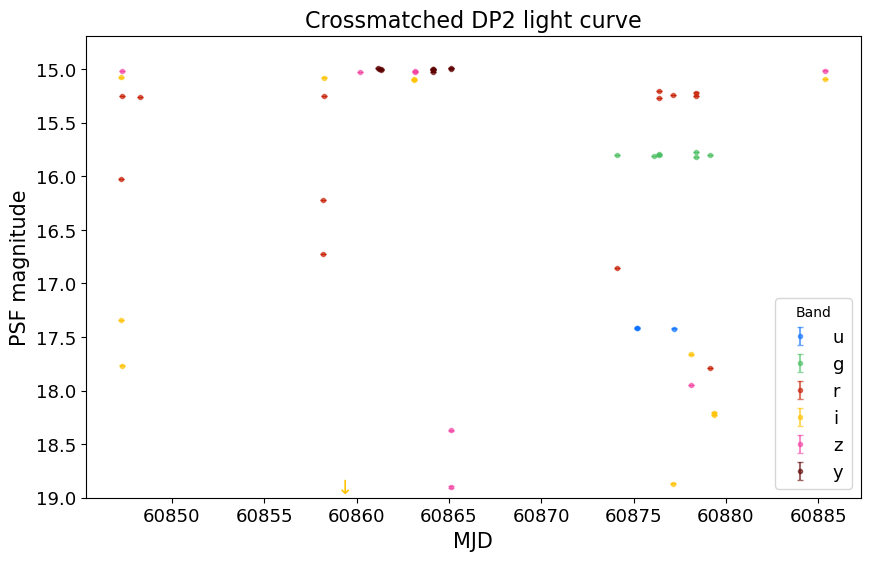

In [34]:
band_colors = {
    "u": "#0c71ff",
    "g": "#49be61",
    "r": "#c61c00",
    "i": "#ffc200",
    "z": "#f341a2",
    "y": "#5d0000",
}

mag_cut = 19.0  # faint-end cutoff (inverted magnitude axis)

fig, ax = plt.subplots(figsize=(10, 6))

# One error-bar series per band, colored by filter, with capped error bars
for band in band_colors:
    grp = lc[lc["band"] == band]
    if len(grp) == 0:
        continue
    ax.errorbar(
        grp["midpointMjdTai"],
        grp["psfMag"],
        yerr=grp["psfMagErr"],
        fmt="o",
        markersize=3,
        alpha=0.6,
        ls="none",
        capsize=2,
        color=band_colors[band],
        label=band,
    )

# Inverted axis, cut off at the faint end (mag 19); brighter objects sit higher
top = lc.loc[lc["psfMag"] <= mag_cut, "psfMag"].min() - 0.3
ax.set_ylim(mag_cut, top)

# Points fainter than the cutoff fall off the bottom: mark each epoch with a
# down-arrow colored by its band
for _, row in lc[lc["psfMag"] > mag_cut].iterrows():
    ax.annotate(
        r"$\downarrow$",
        xy=(row["midpointMjdTai"], mag_cut),
        ha="center",
        va="bottom",  # bottom of the glyph aligns with the axis
        color=band_colors[row["band"]],
        fontsize=14,
        annotation_clip=False,
    )

ax.set_xlabel("MJD")
ax.set_ylabel("PSF magnitude")
ax.set_title("Crossmatched DP2 light curve")
ax.legend(title="Band")
plt.show()


## Summary

With an RSP-sized environment, it's possible to do large crossmatches between DP2 and other large HATS catalogs, as long as you are mindful of the columns being loaded and the Dask Client setup you are specifying for computation. Note how much the computational approach needed to change just by including lightcurves from "objectForcedSource". Being aware of the computational weight of your workflows is it's own learning curve, even as LSDB tries to assist as much as it can with this.

If you're looking for more tips on doing large scale workflows, consult the [LSDB documentation](https://docs.lsdb.io/en/stable/tutorials/dask-cluster-tips.html).

## About
**Author(s):**Doug Branton

**Last updated on:** July 22, 2026

If you use lsdb for published research, please cite following [instructions](https://docs.lsdb.io/en/stable/citation.html).